In [81]:
#%%
import math
import numpy as np

import inspect
import importlib

import scipy.interpolate
from scipy import stats

import matplotlib
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
from matplotlib import ticker, cm
from matplotlib import patches as mpatches
import matplotlib.lines as mlines
from matplotlib import colormaps


plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 16

import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
from plotly.offline import plot
pio.renderers.default = "svg"

import sys
import os
parent_directory = os.path.dirname(os.getcwd())
sys.path.append(parent_directory)
#sys.path.append(os.path.dirname(parent_directory))
#sys.path.append(os.path.dirname(os.path.dirname(parent_directory)))

from IoT_node_models.Energy_model                        import *
from IoT_node_models.Energy_model.Wireless_communication import *
from IoT_node_models.Hardware_Modules                    import *
from IoT_node_models.Analysis                            import *

from fft_architecture_exploration                        import *

path_to_save_svg = "Saved_Data"


rng = np.random.default_rng(42)

In [82]:
dictColor = {"DeepBlue"     :"#095256",
             "LightBlue"    :"#01a7c2",
             "UnitedBlue"   :"#6290c8",
             "CerulBlue"    :"#6096ba",
             "Green"        :"#44af69",
             "LightRed"     :"#f8333c",
             "DeepRed"      :"#a22c29",
             "Orange"       :"#fcab10",
             "Sandy"        :"#fc9e4F",
             "Olivine"      :"#9ab87a",
             "CarolinaBlue" :"#009DDC"}
listColor = list(dictColor.values())

In [83]:

import matplotlib.colors as mcolors

# Define base colors for each row
base_colors = {
    'red': '#f8333c',      # LightRed as base
    'blue': "#64ABD4",     # DeepBlue as base  
    'green': '#44af69',    # Green as base
    'orange': '#fcab10',   # Orange as base
    'purple': '#800080'    # Standard purple as base
}

# Create 10 nuances for each color by varying lightness
color_array = np.zeros((5, 10), dtype=object)

for i, (color_name, base_hex) in enumerate(base_colors.items()):
    base_rgb = mcolors.hex2color(base_hex)
    for j in range(10):
        # Create lighter/darker variations by scaling RGB values
        # Use a non-linear scaling for better visual distribution
        scale = 0.5 + 0.5 * (j / 9) ** 0.7  # 0.5 to 1.0 with curve
        if color_name == 'purple':
            # For purple, create a nice gradient from dark to light
            lightness = j / 9.0  # 0 to 1
            if j < 5:
                # Dark to medium purples
                r = 0.5 + 0.3 * (j / 4.0)
                b = 0.5 + 0.3 * (j / 4.0)
                g = 0.0 + 0.2 * (j / 4.0)
            else:
                # Medium to light purples
                r = 0.8 + 0.2 * ((j - 5) / 4.0)
                b = 0.8 + 0.2 * ((j - 5) / 4.0)
                g = 0.4 + 0.4 * ((j - 5) / 4.0)
            color_array[i, j] = mcolors.rgb2hex((r, g, b))
        else:
            # For other colors, scale from darker to lighter
            if j < 5:
                # Darker variations (scale down)
                scaled_rgb = tuple(max(0, min(1, c * (0.4 + 0.6 * (j / 4.0)))) for c in base_rgb)
            else:
                # Lighter variations (scale up)
                scaled_rgb = tuple(max(0, min(1, c * (1.0 + 0.6 * ((j - 5) / 4.0)))) for c in base_rgb)
            color_array[i, j] = mcolors.rgb2hex(scaled_rgb)

# Rename rows for clarity
color_names = ['red', 'blue', 'green', 'orange', 'purple']

In [84]:



importlib.reload(sys.modules['fft_architecture_exploration'])
from fft_architecture_exploration import * 

In [85]:

baseline_area    = 0.6 #10
baseline_energy  = nFFT* 5.7e-9
baseline_latency = nFFT* 80
baseline_power   = baseline_energy / baseline_latency

In [86]:
# ----------------------------------------------------------------------
#           RATIO
# ----------------------------------------------------------------------


para_theor_Speedup        = baseline_latency        / para_theor_Latency                                
para_theor_Power          = para_theor_Energy       / para_theor_Latency
   
pipePara_theor_Speedup    = baseline_latency            / pipePara_theor_Latency                                
pipePara_theor_Power      = pipePara_theor_Energy       / pipePara_theor_Latency 

pipe_theor_Speedup        = baseline_latency        / pipe_theor_Latency                                
pipe_theor_Power          = pipe_theor_Energy       / pipe_theor_Latency

# ----------------------------------------------------------------------

theor_Area             = np.array([pipe_theor_Area         ,  para_theor_Area     ,  pipePara_theor_Area])
theor_Latency          = np.array([pipe_theor_Latency      ,  para_theor_Latency  ,  pipePara_theor_Latency])
theor_Energy           = np.array([pipe_theor_Energy       ,  para_theor_Energy   ,  pipePara_theor_Energy])
theor_Speedup          = np.array([pipe_theor_Speedup      ,  para_theor_Speedup  ,  pipePara_theor_Speedup])                              
theor_Power            = np.array([pipe_theor_Power        ,  para_theor_Power    ,  pipePara_theor_Power]) 

# ----------------------------------------------------------------------

para_theor_area_ratio    = (para_theor_Area+baseline_area)    / baseline_area
para_theor_power_ratio   = para_theor_Power   / baseline_power
para_theor_energy_ratio  = para_theor_Energy  / baseline_energy
para_theor_latency_ratio = para_theor_Latency / baseline_latency
para_theor_speedup_ratio = 1/(para_theor_latency_ratio)


# ----------------------------------------------------------------------
pipe_theor_area_ratio    = (pipe_theor_Area+baseline_area)    / baseline_area
pipe_theor_power_ratio   = pipe_theor_Power   / baseline_power
pipe_theor_energy_ratio  = pipe_theor_Energy  / baseline_energy
pipe_theor_latency_ratio = pipe_theor_Latency / baseline_latency
pipe_theor_speedup_ratio = 1/(pipe_theor_latency_ratio)


# ----------------------------------------------------------------------
pipePara_theor_area_ratio    = (pipePara_theor_Area+baseline_area)    / baseline_area
pipePara_theor_power_ratio   = pipePara_theor_Power   / baseline_power
pipePara_theor_energy_ratio  = pipePara_theor_Energy  / baseline_energy
pipePara_theor_latency_ratio = pipePara_theor_Latency / baseline_latency
pipePara_theor_speedup_ratio = 1/(pipePara_theor_latency_ratio)

# ----------------------------------------------------------------------


theor_area_ratio        = np.array([pipe_theor_area_ratio       , para_theor_area_ratio    , pipePara_theor_area_ratio])
theor_power_ratio       = np.array([pipe_theor_power_ratio      , para_theor_power_ratio   , pipePara_theor_power_ratio])
theor_energy_ratio      = np.array([pipe_theor_energy_ratio     , para_theor_energy_ratio  , pipePara_theor_energy_ratio])
theor_latency_ratio     = np.array([pipe_theor_latency_ratio    , para_theor_latency_ratio , pipePara_theor_latency_ratio])                              
theor_speedup_ratio     = np.array([pipe_theor_speedup_ratio    , para_theor_speedup_ratio , pipePara_theor_speedup_ratio]) 

In [87]:



#----------------------------------------------------------------------------------

our_Area           = np.array([0.119    , 0.123    , 0.129    , 0.141    ] )    
our_NFFT           = np.array([4096     , 4096     , 4096     , 4096     ] )                 
our_Latency_pFFT   = np.array([98423    , 49250    , 32883    , 24723    ] )                
our_Energy_pFFT    = np.array([3388.9   , 1922.4   , 1434.1   , 1197.6    ] ) *1e-9 

our_Latency        = our_Latency_pFFT   
our_Energy         = our_Energy_pFFT       
our_Speedup        = baseline_latency / our_Latency                                
our_Power          = our_Energy       / our_Latency  

our_area_ratio    = (our_Area+baseline_area)    / baseline_area
our_power_ratio   = our_Power   / baseline_power
our_energy_ratio  = our_Energy  / baseline_energy
our_latency_ratio = our_Latency / baseline_latency
our_speedup_ratio = 1/(our_latency_ratio)

#----------------------------------------------------------------------------------
soA_name          =           [ "Pereira 22" , "Berta. 21 ", "Gonz. 24",  "Yang 21", "Mahdavi 19", "Shih 18", "Tian 19"  , "Paul 25"  ]         #"Deng 23"
soA_type          =           [ "Memory-b"   , "Memory-b"  , "Memory-b",  "Pipel." , "Pipel."    , "Pipel." , "Memory-b" , "Memory-b" ]         #"Pipel." 
soa_Area_FFT       = np.array([    0.185     , 0.185       , 1.08      ,  1.83     , 0.57        , 1.09     ,0.84        , 3.8        ] )       #0.48                        
soa_NFFT           = np.array([    256       , 1024        , 1024      ,  2048     , 2048        , 2048     ,4096        , 4096       ] )       #1024                       
soa_Latency_pFFT   = np.array([    1025      , 3005        , 1320      ,  2048     , 1200        , 2048     ,5120        , 605        ] )       #245                         
soa_Energy_pFFT    = np.array([    187.23    , 1054.78     , 297.92    ,  260.31   , 600.82      , 541.60   ,599.04      , 495.67     ] ) *1e-9 #22.94      

soa_Area           = scale_area    (area= soa_Area_FFT,        nfft_ref = 4096, nfft = soa_NFFT, acc_type =soA_type)    
soa_Latency        = scale_latency (latency= soa_Latency_pFFT, nfft_ref = 4096, nfft = soa_NFFT, acc_type =soA_type)                      
soa_Energy         = soa_Energy_pFFT  * (4096*12/(soa_NFFT*np.log2(soa_NFFT)))     
 
soa_Speedup        = baseline_latency / soa_Latency                               
soa_Power          = soa_Energy       / soa_Latency  

soa_area_ratio    = (soa_Area+baseline_area)    / baseline_area
soa_power_ratio   = soa_Power   / baseline_power
soa_energy_ratio  = soa_Energy  / baseline_energy
soa_latency_ratio = soa_Latency / baseline_latency
soa_speedup_ratio = 1/(soa_latency_ratio)

#----------------------------------------------------------------------------------
soA_pt_name          =           [ "Liu 18"   ]   
soA_pt_type          =           [ "Memory-b" ]   
soa_pt_Area_FFT       = np.array([   1.67     ] ) 
soa_pt_NFFT           = np.array([   4096     ] ) 
soa_pt_Latency_pFFT   = np.array([   768      ] ) 
soa_pt_Energy_pFFT    = np.array([  240.98    ] ) *1e-9

soa_pt_Area           = scale_area    (area= soa_pt_Area_FFT,        nfft_ref = 4096, nfft = soa_pt_NFFT, acc_type =soA_pt_type)    
soa_pt_Latency        = scale_latency (latency= soa_pt_Latency_pFFT, nfft_ref = 4096, nfft = soa_pt_NFFT, acc_type =soA_pt_type)                      
soa_pt_Energy         = soa_pt_Energy_pFFT  * (4096*12/(soa_pt_NFFT*np.log2(soa_pt_NFFT)))     
 
soa_pt_Speedup        = baseline_latency / soa_pt_Latency                               
soa_pt_Power          = soa_pt_Energy    / soa_pt_Latency  

soa_pt_area_ratio    = (soa_pt_Area+baseline_area)    / baseline_area
soa_pt_power_ratio   = soa_pt_Power   / baseline_power
soa_pt_energy_ratio  = soa_pt_Energy  / baseline_energy
soa_pt_latency_ratio = soa_pt_Latency / baseline_latency
soa_pt_speedup_ratio = 1/(soa_pt_latency_ratio)



In [88]:
analysis_Mem_type  = np.array([1]) # 0: 1xSP SRAM,   1: 2xSP SRAM, 2: 2xHalf-size SP SRAM,  3: 1xDP SRAM
analysis_nMem_type = len(analysis_Mem_type)

In [118]:

alpha_studied = np.linspace(0.01, 1, 100,endpoint=False)

# ----------------------------------------------------------------------
# 2a. DERIVE RATIOS 
# ----------------------------------------------------------------------

theor_asi_res  = np.zeros((len(alpha_studied),3,arch_Dim,analysis_nMem_type))
theor_ncf_res  = np.zeros((len(alpha_studied),3,arch_Dim,analysis_nMem_type,2))
for k in range(3):
    for i in range(arch_Dim):
        for d, j in enumerate(analysis_Mem_type):
            #k j i theor_area_ratio[k,i,j]i]:.4f},  power_ratio={theor_power_ratio[k,i,j]:.2f}, energy_ratio={theor_energy_ratio[k,i,j]:.2f}, speedup={theor_speedup_ratio[k,i,j]:.2f}")
            print(f"THEOR {k},{j},{i}: area_ratio={theor_area_ratio[k,i,j]:.2f}, area={theor_Area[k,i,j]:.4f},  power_ratio={theor_power_ratio[k,i,j]:.2f}, energy_ratio={theor_energy_ratio[k,i,j]:.2f}, speedup={theor_speedup_ratio[k,i,j]:.2f}")
            theor_asi_res[:,k,i,d]  = asi_function (alpha=alpha_studied, area_ratio=theor_area_ratio[k,i,j], power_ratio=theor_power_ratio[k,i,j],print=False)
            theor_ncf_res[:,k,i,d,0]= (theor_area_ratio[k,i,j]* (alpha_studied)) +  (theor_energy_ratio[k,i,j]* (1-alpha_studied))
            theor_ncf_res[:,k,i,d,1]= (theor_area_ratio[k,i,j]* (alpha_studied)) +  (theor_power_ratio [k,i,j]* (1-alpha_studied))

# ----------------------------------------------------------------------

our_asi_res  = np.zeros((len(alpha_studied),len(our_area_ratio)))
our_ncf_res  = np.zeros((len(alpha_studied),len(our_area_ratio),2))
for i in range(our_area_ratio.shape[0]):
    print(f"OUR {i}      : area_ratio={our_area_ratio[i]:.2f}, area={our_Area[i]:.4f},  power_ratio={our_power_ratio[i]:.2f}, energy_ratio={our_energy_ratio[i]:.2f}, speedup={our_speedup_ratio[i]:.2f}")
    our_asi_res[:,i]  = asi_function (alpha=alpha_studied, area_ratio=our_area_ratio[i], power_ratio=our_power_ratio[i],print=False)
    our_ncf_res[:,i,0]= (our_area_ratio[i]* (alpha_studied)) +  (our_energy_ratio[i]* (1-alpha_studied))
    our_ncf_res[:,i,1]= (our_area_ratio[i]* (alpha_studied)) +  (our_power_ratio[i] * (1-alpha_studied))

# ----------------------------------------------------------------------

soa_asi_res  = np.zeros((len(alpha_studied),len(soa_area_ratio)))
soa_ncf_res  = np.zeros((len(alpha_studied),len(soa_area_ratio),2))
for i in range(soa_area_ratio.shape[0]):
    print(f"SOA {i}      : area_ratio={soa_area_ratio[i]:.2f}, area={soa_Area[i]:.4f},  power_ratio={soa_power_ratio[i]:.2f}, energy_ratio={soa_energy_ratio[i]:.2f}, speedup={soa_speedup_ratio[i]:.2f}")
    soa_asi_res[:,i]  = asi_function (alpha=alpha_studied, area_ratio=soa_area_ratio[i], power_ratio=soa_power_ratio[i],print=False)
    soa_ncf_res[:,i,0]= (soa_area_ratio[i]* (alpha_studied)) +  (soa_energy_ratio[i]* (1-alpha_studied))
    soa_ncf_res[:,i,1]= (soa_area_ratio[i]* (alpha_studied)) +  (soa_power_ratio[i] * (1-alpha_studied))

THEOR 0,1,0: area_ratio=1.33, area=0.1951,  power_ratio=0.80, energy_ratio=0.12, speedup=6.67
THEOR 0,1,1: area_ratio=1.34, area=0.2013,  power_ratio=0.91, energy_ratio=0.07, speedup=13.33
THEOR 0,1,2: area_ratio=1.35, area=0.2074,  power_ratio=1.02, energy_ratio=0.05, speedup=20.00
THEOR 0,1,3: area_ratio=1.36, area=0.2135,  power_ratio=1.14, energy_ratio=0.04, speedup=26.67
THEOR 0,1,4: area_ratio=1.37, area=0.2196,  power_ratio=1.25, energy_ratio=0.04, speedup=33.33
THEOR 1,1,0: area_ratio=1.33, area=0.1951,  power_ratio=0.80, energy_ratio=0.12, speedup=6.67
THEOR 1,1,1: area_ratio=1.40, area=0.2375,  power_ratio=1.23, energy_ratio=0.09, speedup=13.33
THEOR 1,1,2: area_ratio=1.48, area=0.2861,  power_ratio=2.00, energy_ratio=0.07, speedup=26.67
THEOR 1,1,3: area_ratio=1.62, area=0.3722,  power_ratio=3.61, energy_ratio=0.07, speedup=53.33
THEOR 1,1,4: area_ratio=1.97, area=0.5845,  power_ratio=3.97, energy_ratio=0.04, speedup=106.67
THEOR 2,1,0: area_ratio=1.33, area=0.1951,  power_r

Text(0.5, 1.0, 'State-of-the-art KPIs\n')

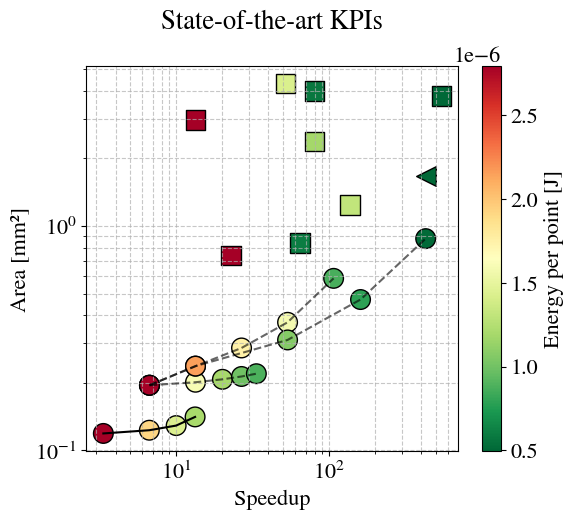

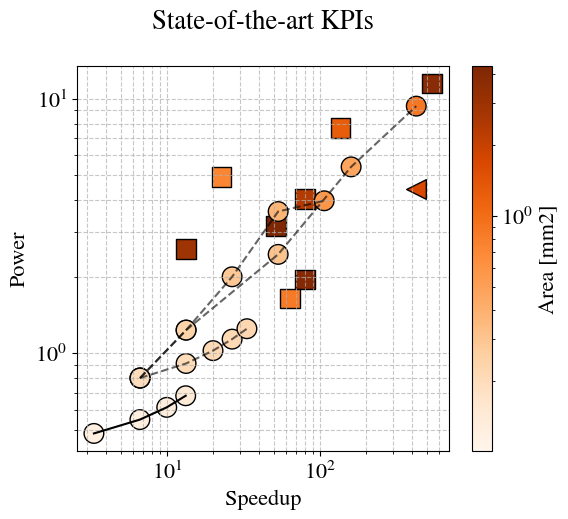

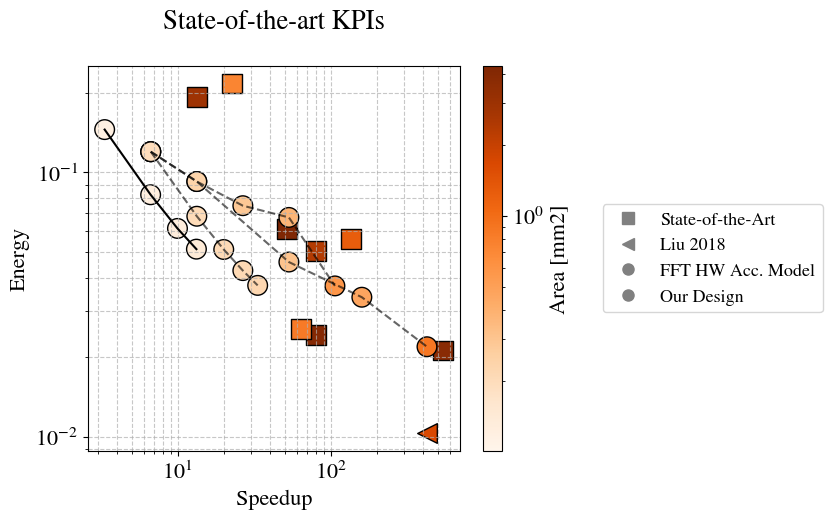

In [119]:
alpha_soa_plot = 1

markersize = 200

soa_patch      = mlines.Line2D([], [], color='gray', marker="s", markersize=8, linewidth=0, label='State-of-the-Art')
soa_pt_patch   = mlines.Line2D([], [], color='gray', marker="<", markersize=8, linewidth=0, label='Liu 2018')
model_patch    = mlines.Line2D([], [], color='gray', marker="o", markersize=8, linewidth=0, label='FFT HW Acc. Model')
our_patch      = mlines.Line2D([], [], color='gray', marker="o", markersize=8, linewidth=0, label='Our Design')

fig, ax = plt.subplots(1,1, figsize=(6, 5))


ax.plot(our_Speedup    , our_Area  , color = "black")
sc = ax.scatter(soa_Speedup   , soa_Area   , s=markersize , c= soa_Energy   ,  cmap='RdYlGn_r', vmin =np.min(soa_Energy)   ,vmax = np.max(pipe_theor_Energy),  marker = 's', edgecolors="black",label="State-of-the-Art",alpha = alpha_soa_plot)  #s=soa_Power*4e12   
sc = ax.scatter(soa_pt_Speedup, soa_pt_Area, s=markersize , c= soa_pt_Energy,  cmap='RdYlGn_r', vmin =np.min(soa_Energy)   ,vmax = np.max(pipe_theor_Energy),  marker = '<', edgecolors="black",label="Liu 2018"        ,alpha=1               )  #s=soa_pt_Power*4e12
sc = ax.scatter(our_Speedup   , our_Area   , s=markersize , c= our_Energy   ,  cmap='RdYlGn_r', vmin =np.min(soa_Energy)   ,vmax = np.max(pipe_theor_Energy),  marker = 'o', edgecolors="black",label="Our Approach"    ,alpha=1               )  #s=our_Power*4e12   

for d, i in enumerate(analysis_Mem_type):
    for j in range(3):
        ax.plot(theor_Speedup[j,:,i], theor_Area[j,:,i], color = 'black', alpha=0.6, linestyle ='--')
        sc = ax.scatter(    theor_Speedup[j,:,i],     theor_Area[j,:,i], s=markersize , c=     theor_Energy[j,:,i],  cmap='RdYlGn_r', vmin =np.min(soa_Energy),vmax = np.max(theor_Energy), alpha=1, marker = 'o', edgecolors="black") #  s=    theor_Power[j,:,i]*4e12

fig.colorbar(sc, ax=ax, label='Energy per point [J]', location='right')

#ax.legend()
#ax.legend(handles=[soa_patch, soa_pt_patch, model_patch, our_patch],fontsize = 13)

ax.set_yscale('log')
ax.set_xscale('log')
ax.grid(True, which='both', linestyle='--', alpha=0.7)
ax.set_ylabel('Area [mm²]')
ax.set_xlabel('Speedup')
ax.set_title('State-of-the-art KPIs\n')

######################################################################################################################
fig, ax = plt.subplots(1,1, figsize=(6, 5))

normArea = colors.LogNorm(vmin=theor_Area.min(), vmax=soa_Area.max())

ax.plot(our_Speedup    , our_power_ratio  , color = "black")        
sc = ax.scatter(soa_Speedup   , soa_power_ratio   , s=markersize , c= soa_Area   ,  norm=normArea, cmap='Oranges', marker = 's', edgecolors="black",label="State-of-the-Art", alpha = alpha_soa_plot) # s=soa_Area*2e3   
sc = ax.scatter(soa_pt_Speedup, soa_pt_power_ratio, s=markersize , c= soa_pt_Area,  norm=normArea, cmap='Oranges', marker = '<', edgecolors="black",label="Liu 2018"                                ) # s=soa_pt_Area*2e3
sc = ax.scatter(our_Speedup   , our_power_ratio   , s=markersize , c= our_Area   ,  norm=normArea, cmap='Oranges', marker = 'o', edgecolors="black",label="Our Approach"                            ) # s=our_Area*2e3   

for i in analysis_Mem_type:
    for j in range(3):
        ax.plot(theor_Speedup[j,:,i], theor_power_ratio[j,:,i], color = 'black', alpha=0.6, linestyle ='--')
        sc = ax.scatter(    theor_Speedup[j,:,i],     theor_power_ratio[j,:,i], s=markersize , c=     theor_Area[j,:,i],  norm=normArea, cmap='Oranges', alpha=1, marker = 'o', edgecolors="black") # s=    theor_Area[j,:,i]*2e3

fig.colorbar(sc, ax=ax, label='Area [mm2]', location='right')

#ax.legend()
#ax.legend(handles=[soa_patch, soa_pt_patch, model_patch, our_patch],fontsize = 13)

ax.set_yscale('log')
ax.set_xscale('log')
ax.grid(True, which='both', linestyle='--', alpha=0.7)
ax.set_ylabel('Power')
ax.set_xlabel('Speedup')
ax.set_title('State-of-the-art KPIs\n')


######################################################################################################################
fig, ax = plt.subplots(1,1, figsize=(6, 5))

ax.plot(our_Speedup    , our_energy_ratio  , color = "black")
sc = ax.scatter(soa_Speedup   , soa_energy_ratio   , s = markersize , c= soa_Area    ,norm=normArea,  cmap='Oranges',  marker = 's', edgecolors="black", label="State-of-the-Art", alpha = alpha_soa_plot) #s=soa_Area*2e3   
sc = ax.scatter(soa_pt_Speedup, soa_pt_energy_ratio, s = markersize , c= soa_pt_Area ,norm=normArea,  cmap='Oranges',  marker = '<', edgecolors="black", label="Liu 2018"                                ) #s=soa_pt_Area*2e3
sc = ax.scatter(our_Speedup   , our_energy_ratio   , s = markersize , c= our_Area    ,norm=normArea,  cmap='Oranges',  marker = 'o', edgecolors="black", label="Our Approach"                            ) #s=our_Area*2e3   

for i in analysis_Mem_type:
    for j in range(3):
        ax.plot(theor_Speedup[j,:,i], theor_energy_ratio[j,:,i], color = 'black', alpha=0.6, linestyle ='--')
        sc = ax.scatter(    theor_Speedup[j,:,i],     theor_energy_ratio[j,:,i], s = markersize ,norm=normArea, c=     theor_Area[j,:,i],  cmap='Oranges',   alpha=1, marker = 'o', edgecolors="black") # s=    theor_Area[j,:,i]*2e3
        
fig.colorbar(sc, ax=ax, label='Area [mm2]', location='right')


#ax.legend()
ax.legend(handles=[soa_patch, soa_pt_patch, model_patch, our_patch],fontsize = 13, loc='right', bbox_to_anchor=(2,0.5) )
ax.set_yscale('log')
ax.set_xscale('log')
ax.grid(True, which='both', linestyle='--', alpha=0.7)
ax.set_ylabel('Energy')
ax.set_xlabel('Speedup')
ax.set_title('State-of-the-art KPIs\n')

C:\Users\Pol Maistriaux\AppData\Local\Temp\ipykernel_32052\1766159355.py:24: UserWarning:

Attempt to set non-positive xlim on a log-scaled axis will be ignored.



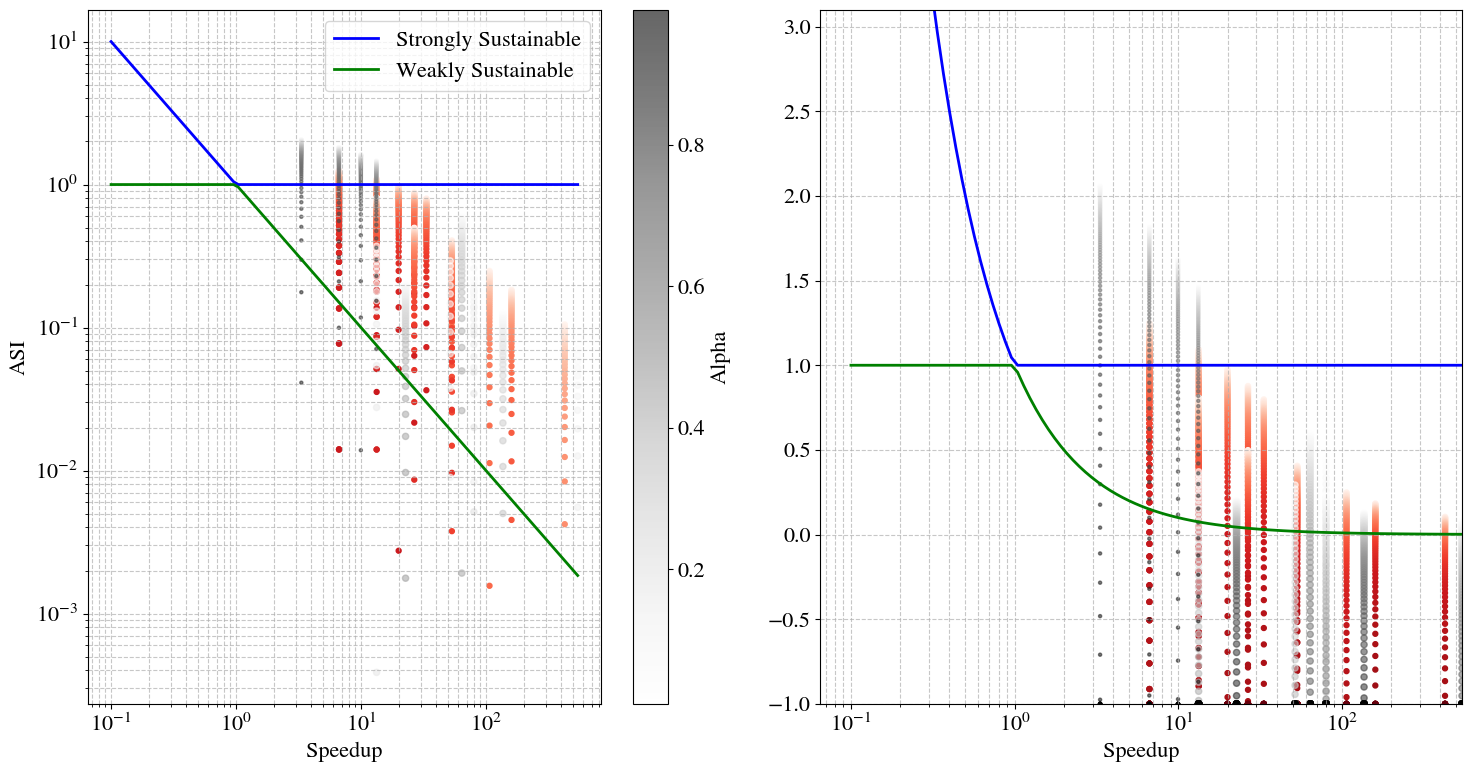

In [91]:
# ASI Framework separations
speedup_space = np.logspace(-1, np.log10(np.max(soa_speedup_ratio)), 100)

sep_strongly_sustainable = 1/speedup_space
sep_weakly_sustainable   = 1/speedup_space

sep_strongly_sustainable[np.where(sep_strongly_sustainable<1)] =1
sep_weakly_sustainable  [np.where(sep_weakly_sustainable>1)]   =1


# Plot the operation footprint vs FFT throughput
fig, ax = plt.subplots(1,2,figsize=(15, 8))
ax[0].set_ylabel('ASI')
ax[0].loglog(speedup_space, sep_strongly_sustainable, 'b', linewidth=2, label='Strongly Sustainable')
ax[0].loglog(speedup_space, sep_weakly_sustainable,   'g', linewidth=2, label='Weakly Sustainable')
ax[1].plot(speedup_space, sep_strongly_sustainable, 'b', linewidth=2, label='Strongly Sustainable')
ax[1].plot(speedup_space, sep_weakly_sustainable,   'g', linewidth=2, label='Weakly Sustainable')

ax[1].set_xscale('log')

ax[0].set_xlabel('Speedup')
ax[1].set_xlabel('Speedup')
ax[1].set_ylim([-1,np.max(our_asi_res)*1.5])
ax[1].set_xlim([0,np.max(soa_speedup_ratio)])

ax[0].grid(True, which='both', linestyle='--', alpha=0.7)
ax[1].grid(True, which='both', linestyle='--', alpha=0.7)

for k in range(3):
    for i in range(arch_Dim):
        for d, j in enumerate(analysis_Mem_type):
            p = ax[0].scatter(np.ones(len(alpha_studied))*theor_speedup_ratio[k,i,j],   np.maximum(theor_asi_res[:,k,i,d],-1),   c=alpha_studied,cmap="Reds",  s=50, marker='.')
            p = ax[1].scatter(np.ones(len(alpha_studied))*theor_speedup_ratio[k,i,j],   np.maximum(theor_asi_res[:,k,i,d],-1),   c=alpha_studied,cmap="Reds",  s=50, marker='.')

#Add our accelerator
for i in range(soa_area_ratio.shape[0]):
    p = ax[0].scatter(np.ones(len(alpha_studied))*soa_speedup_ratio[i],   np.maximum(soa_asi_res[:,i],-1),   c=alpha_studied,cmap="Greys",  s=20, alpha=0.6)
    p = ax[1].scatter(np.ones(len(alpha_studied))*soa_speedup_ratio[i],   np.maximum(soa_asi_res[:,i],-1),   c=alpha_studied,cmap="Greys",  s=20, alpha=0.6)
fig.colorbar(p,ax=ax[0],orientation='vertical',label='Alpha')

# Add our accelerator
for i in range(our_area_ratio.shape[0]):
    p = ax[0].scatter(np.ones(len(alpha_studied))*our_speedup_ratio[i],   np.maximum(our_asi_res[:,i],-1),   c=alpha_studied,cmap="Greys",  s=20, marker='.', alpha=0.6)
    p = ax[1].scatter(np.ones(len(alpha_studied))*our_speedup_ratio[i],   np.maximum(our_asi_res[:,i],-1),   c=alpha_studied,cmap="Greys",  s=20, marker='.', alpha=0.6)



ax[0].legend()
# Add legend
fig.tight_layout()
plt.show()


C:\Users\Pol Maistriaux\AppData\Local\Temp\ipykernel_32052\2497761558.py:39: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



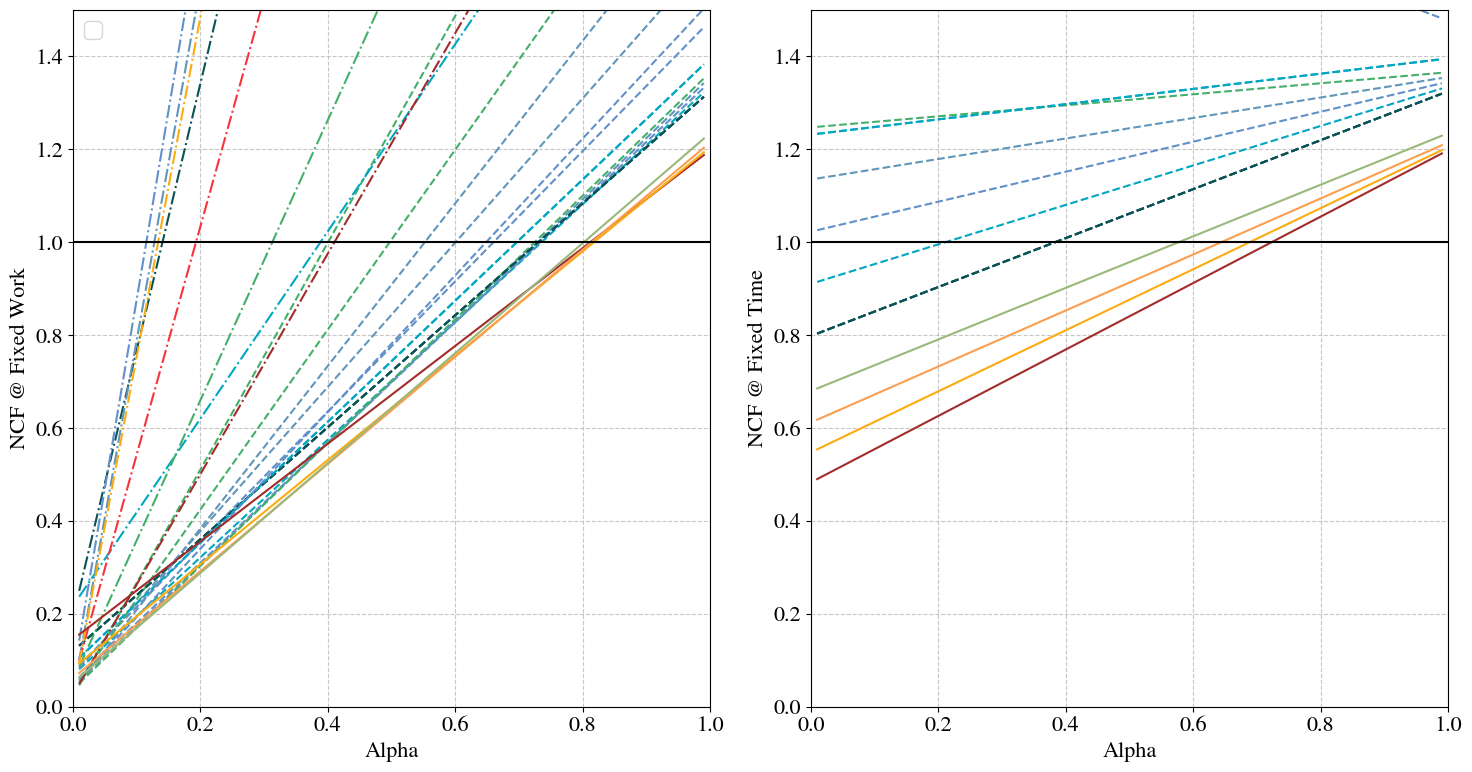

In [92]:
# Plot the operation footprint vs FFT throughput
fig, ax = plt.subplots(1,2,figsize=(15, 8))


ax[0].set_xlabel('ALpha')
ax[1].set_xlabel('ALpha')

ax[0].grid(True, which='both', linestyle='--', alpha=0.7)
ax[1].grid(True, which='both', linestyle='--', alpha=0.7)

# Add our accelerator

for k in range(3):
    for i in range(arch_Dim):
        for d, j in enumerate(analysis_Mem_type):
            p = ax[0].plot(alpha_studied,   theor_ncf_res[:,k,i,d,0],   color = listColor[i] , linestyle ='--')
            p = ax[1].plot(alpha_studied,   theor_ncf_res[:,k,i,d,1],   color = listColor[i] , linestyle ='--')

# Add our accelerator
for i in range(soa_area_ratio.shape[0]):
    p = ax[0].plot(alpha_studied,   soa_ncf_res[:,i,0],   color = listColor[i] , linestyle ='-.')
    p = ax[1].plot(alpha_studied,   soa_ncf_res[:,i,1],   color = listColor[i] , linestyle ='-.')


for i in range(our_area_ratio.shape[0]):
    p = ax[0].plot(alpha_studied,   our_ncf_res[:,i,0],   color = listColor[i+6] , linestyle ='-')
    p = ax[1].plot(alpha_studied,   our_ncf_res[:,i,1],   color = listColor[i+6] , linestyle ='-')

ax[0].hlines(y=1,xmin = 0, xmax=1, color= "black")
ax[1].hlines(y=1,xmin = 0, xmax=1, color= "black")

ax[0].set_xlim([0,1])
ax[1].set_xlim([0,1])

ax[0].set_xlabel("Alpha")
ax[1].set_xlabel("Alpha")
ax[0].set_ylabel("NCF @ Fixed Work")
ax[1].set_ylabel("NCF @ Fixed Time")
ax[0].legend()

ax[0].set_ylim([0,1.5])
ax[1].set_ylim([0,1.5])
# Add legend
fig.tight_layout()
plt.show()


# Monte Carlo from architecture exploration

In [101]:
N = 10000


mc_Mem_type  = np.array([2]) # 0: 1xSP SRAM,   1: 2xSP SRAM, 2: 2xHalf-size SP SRAM,  3: 1xDP SRAM
mc_nMem_type = len(mc_Mem_type)

# Random architecture selection
mc_mem  = rng.integers(low=0,high=mc_nMem_type, size= N)
mc_strat= rng.integers(low=0,high=3,            size= N)
mc_arch = rng.integers(low=0,high=arch_Dim,     size= N)

mc_mem_idx = mc_Mem_type[mc_mem]

mc_area_overhead     = theor_Area          [mc_strat,mc_arch,mc_mem_idx] 
mc_power_ratio       = theor_power_ratio   [mc_strat,mc_arch,mc_mem_idx] 
mc_energy_ratio      = theor_energy_ratio  [mc_strat,mc_arch,mc_mem_idx] 
mc_speedup_ratio     = theor_speedup_ratio [mc_strat,mc_arch,mc_mem_idx] 

# Impairment to speedup
mc_speedup_factor = rng.uniform(low=0.9, high=1, size=N)
mc_speedup_ratio  = mc_speedup_ratio*mc_speedup_factor


# Impairment to energy
mc_energy_factor = rng.uniform(low=1, high=1.5, size=N)
mc_energy_ratio  = mc_energy_ratio*mc_energy_factor


mc_power_ratio = (mc_energy_ratio) * mc_speedup_ratio

# Impairment to area
mc_area_factor = rng.uniform(low=1, high=1.5, size=N)
mc_area_ratio  = ((mc_area_overhead*mc_area_factor)+baseline_area)/baseline_area

mc_alpha = rng.uniform(low=0.001, high=0.999, size=N)
#mc_alpha = rng.beta(a=0.5,b=0.5, size=N)

# ----------------------------------------------------------------------
# 3. XASI METRIC
# ----------------------------------------------------------------------
mc_asi_res     = asi_function(alpha=mc_alpha, area_ratio=mc_area_ratio, power_ratio=mc_power_ratio,print=False)
mc_ncf_fw_res  = (mc_area_ratio* (mc_alpha)) +  (mc_energy_ratio   * (1-mc_alpha))
mc_ncf_ft_res  = (mc_area_ratio* (mc_alpha)) +  (mc_power_ratio    * (1-mc_alpha))

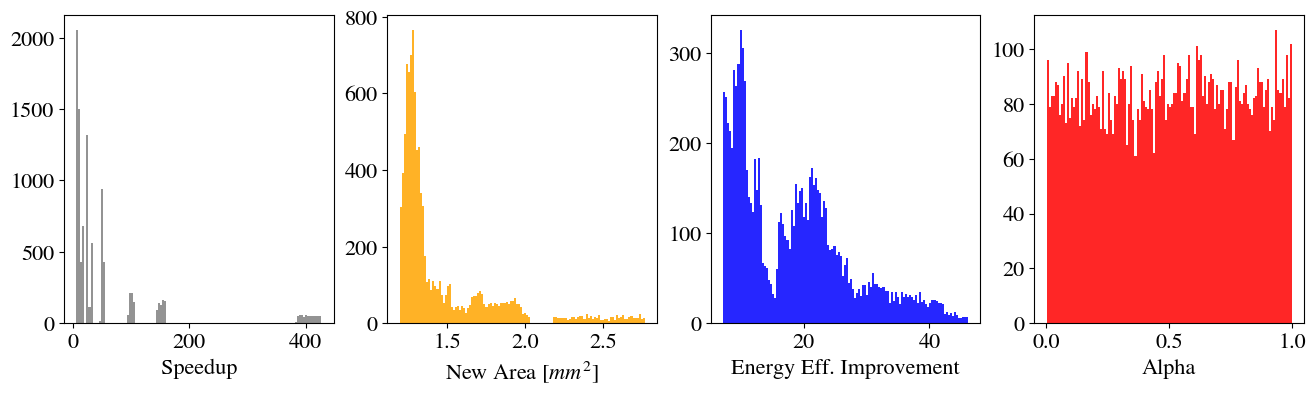

Text(0.5, 1.0, 'Outcome across design space\n(color = sustainability outcome)')

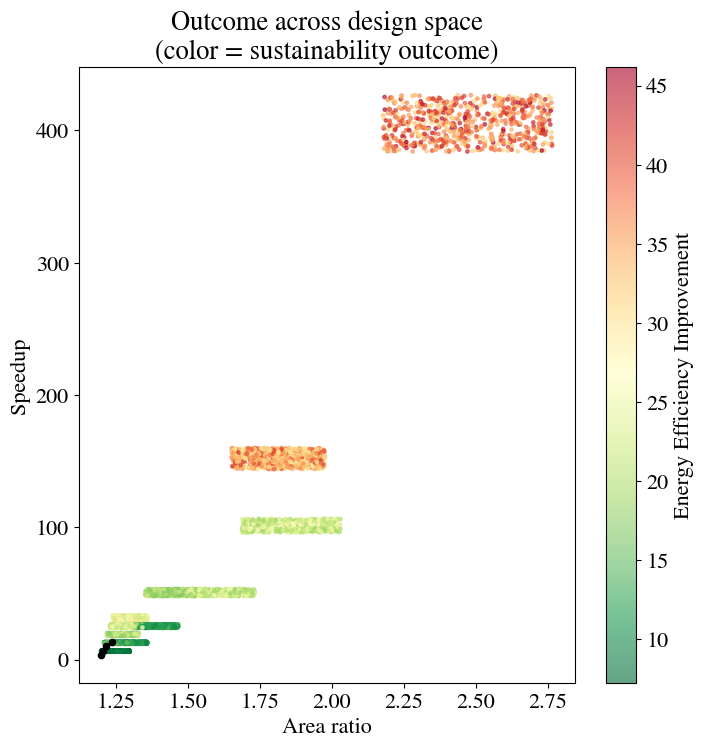

In [102]:


fig, ax = plt.subplots(1,4, figsize=(16,4))

ax[0].hist(mc_speedup_ratio, bins=120, color='Gray', alpha=0.85, edgecolor='none')
ax[0].set_xlabel('Speedup')
ax[1].hist(mc_area_ratio, bins=120, color='Orange', alpha=0.85, edgecolor='none')
ax[1].set_xlabel('New Area [$mm^2$]')
ax[2].hist(1/mc_energy_ratio, bins=120, color='Blue', alpha=0.85, edgecolor='none')
ax[2].set_xlabel('Energy Eff. Improvement')
ax[3].hist(mc_alpha, bins=120, color='Red', alpha=0.85, edgecolor='none')
ax[3].set_xlabel('Alpha')

plt.show()

##############################################################################################
fig, axes = plt.subplots(1,1, figsize=(8, 8))

ax = axes #axes[1, 0]
sc = ax.scatter(mc_area_ratio, mc_speedup_ratio, c=1/mc_energy_ratio,
                 cmap='RdYlGn_r', s=6, vmin=np.min(1/mc_energy_ratio), vmax=np.max(1/mc_energy_ratio), alpha=0.6)

plt.colorbar(sc, ax=ax, label='Energy Efficiency Improvement')

for i in range(our_Area.shape[0]):
    ax.scatter (our_area_ratio[i], our_Speedup[i], s = 20, c ='black')

ax.set_xlabel('Area ratio')
ax.set_ylabel('Speedup')
ax.set_title('Outcome across design space\n(color = sustainability outcome)')



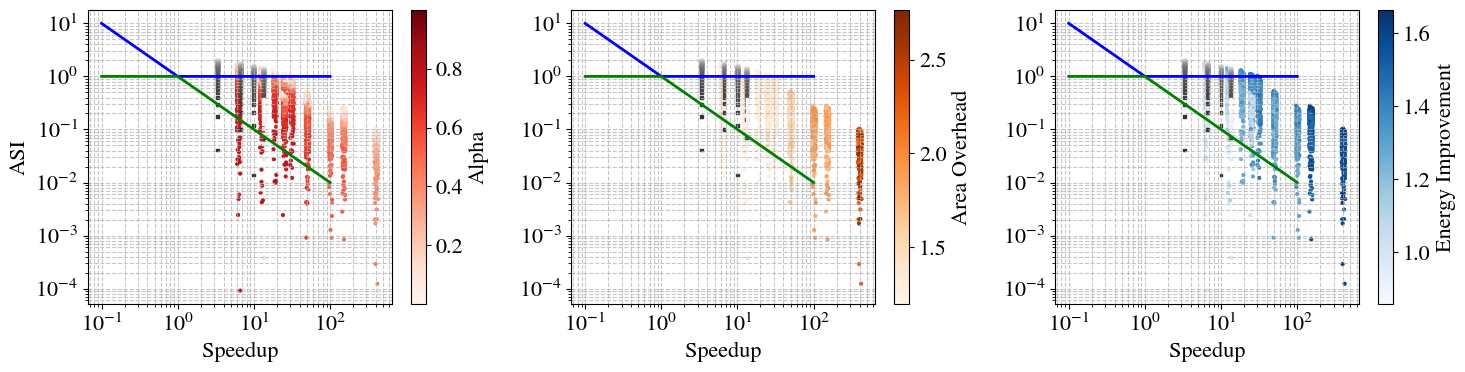

In [103]:
# ASI Framework separations
speedup_space = np.logspace(-1, 2, 100)

sep_strongly_sustainable = 1/speedup_space
sep_weakly_sustainable   = 1/speedup_space

sep_strongly_sustainable[np.where(sep_strongly_sustainable<1)] =1
sep_weakly_sustainable  [np.where(sep_weakly_sustainable>1)]   =1

# Plot the operation footprint vs FFT throughput
fig, ax = plt.subplots(1,3,figsize=(15, 4))
ax[0].set_ylabel('ASI')
for this_ax in ax:
    this_ax.loglog(speedup_space, sep_strongly_sustainable, 'b', linewidth=2, label='Strongly Sustainable')
    this_ax.loglog(speedup_space, sep_weakly_sustainable,   'g', linewidth=2, label='Weakly Sustainable')

    this_ax.set_xlabel('Speedup')
    this_ax.grid(True, which='both', linestyle='--', alpha=0.7)
    #this_ax.set_xlim(10, 1e7)

# Add our accelerator
p = ax[0].scatter(mc_speedup_ratio,   mc_asi_res,   c=mc_alpha,cmap="Reds",  s=4, label='Our Accelerator')
fig.colorbar(p,ax=ax[0],orientation='vertical',label='Alpha')

p = ax[1].scatter(mc_speedup_ratio,   mc_asi_res,   c=mc_area_ratio,cmap="Oranges",  s=4, label='Our Accelerator') #np.log10(area_overhead)
fig.colorbar(p,ax=ax[1],orientation='vertical',label='Area Overhead')

p = ax[2].scatter(mc_speedup_ratio,   mc_asi_res,   c=np.log10(1/mc_energy_ratio),cmap="Blues",  s=4, label='Our Accelerator')
fig.colorbar(p,ax=ax[2],orientation='vertical',label='Energy Improvement')


# Add our accelerator
for i in range(our_area_ratio.shape[0]):
    p = ax[0].scatter(np.ones(len(alpha_studied))*our_speedup_ratio[i],   np.maximum(our_asi_res[:,i],-1),   c=alpha_studied,cmap="Greys",  s=4, marker='s')
    p = ax[1].scatter(np.ones(len(alpha_studied))*our_speedup_ratio[i],   np.maximum(our_asi_res[:,i],-1),   c=alpha_studied,cmap="Greys",  s=4, marker='s')
    p = ax[2].scatter(np.ones(len(alpha_studied))*our_speedup_ratio[i],   np.maximum(our_asi_res[:,i],-1),   c=alpha_studied,cmap="Greys",  s=4, marker='s')

p = ax[0].scatter(np.ones(len(alpha_studied))*soa_speedup_ratio[0],   np.maximum(soa_asi_res[:,0],-1),   c=alpha_studied,cmap="Greys",  s=4, marker='s')
p = ax[1].scatter(np.ones(len(alpha_studied))*soa_speedup_ratio[0],   np.maximum(soa_asi_res[:,0],-1),   c=alpha_studied,cmap="Greys",  s=4, marker='s')
p = ax[2].scatter(np.ones(len(alpha_studied))*soa_speedup_ratio[0],   np.maximum(soa_asi_res[:,0],-1),   c=alpha_studied,cmap="Greys",  s=4, marker='s')
# Add legend
fig.tight_layout()
plt.show()


C:\Users\Pol Maistriaux\AppData\Local\Temp\ipykernel_32052\95151438.py:20: UserWarning:

Attempt to set non-positive xlim on a log-scaled axis will be ignored.



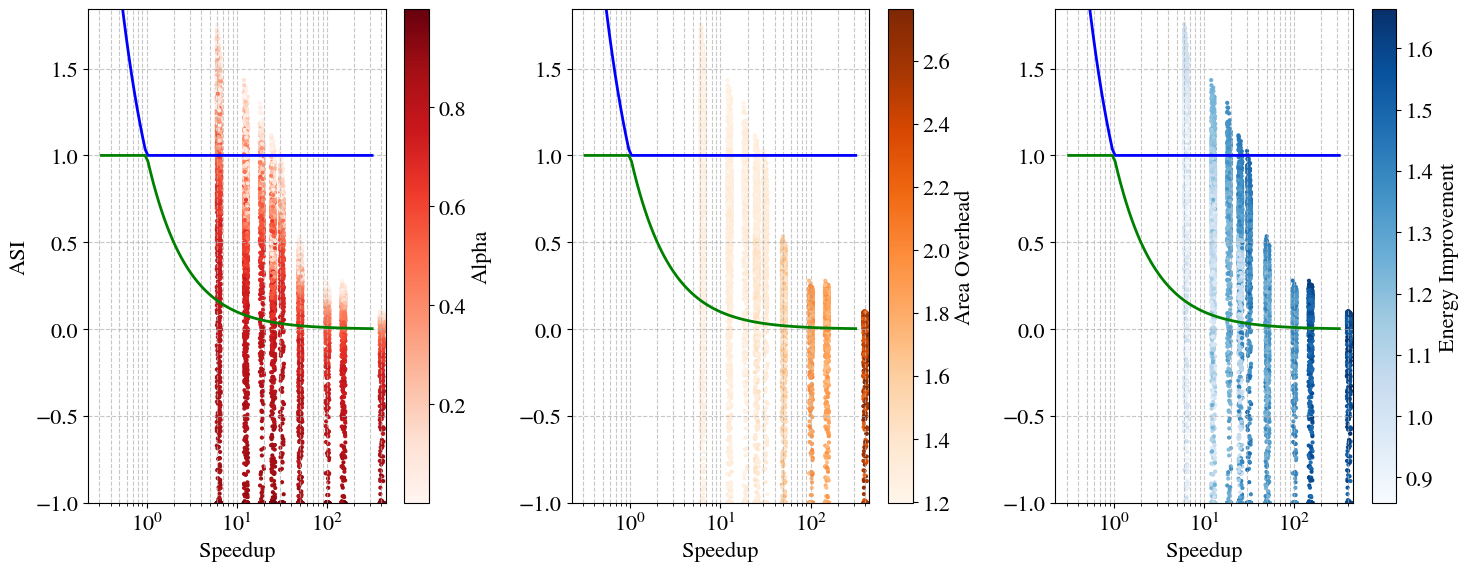

In [104]:
# ASI Framework separations
speedup_space = np.logspace(-0.5, 2.5, 100)

sep_strongly_sustainable = 1/speedup_space
sep_weakly_sustainable   = 1/speedup_space

sep_strongly_sustainable[np.where(sep_strongly_sustainable<1)] =1
sep_weakly_sustainable  [np.where(sep_weakly_sustainable>1)]   =1

# Plot the operation footprint vs FFT throughput
fig, ax = plt.subplots(1,3,figsize=(15, 6))
ax[0].set_ylabel('ASI')
for this_ax in ax:
    this_ax.plot(speedup_space, sep_strongly_sustainable, 'b', linewidth=2, label='Strongly Sustainable')
    this_ax.plot(speedup_space, sep_weakly_sustainable,   'g', linewidth=2, label='Weakly Sustainable')

    this_ax.set_xscale('log')
    this_ax.set_xlabel('Speedup')
    this_ax.set_ylim([-1,1.05*np.max(mc_asi_res)])
    this_ax.set_xlim([0,1.05*np.max(mc_speedup_ratio)])
    this_ax.grid(True, which='both', linestyle='--', alpha=0.7)
    #this_ax.set_xlim(10, 1e7)

# Add our accelerator
p = ax[0].scatter(mc_speedup_ratio,   np.maximum(mc_asi_res,-1),   c=mc_alpha,cmap="Reds",  s=4, label='Our Accelerator')
fig.colorbar(p,ax=ax[0],orientation='vertical',label='Alpha')
p = ax[1].scatter(mc_speedup_ratio,   np.maximum(mc_asi_res,-1),   c=mc_area_ratio,cmap="Oranges",  s=4, label='Our Accelerator') #np.log10(area_overhead)
fig.colorbar(p,ax=ax[1],orientation='vertical',label='Area Overhead')
p = ax[2].scatter(mc_speedup_ratio,   np.maximum(mc_asi_res,-1),   c=np.log10(1/mc_energy_ratio),cmap="Blues",  s=4, label='Our Accelerator')
fig.colorbar(p,ax=ax[2],orientation='vertical',label='Energy Improvement')

# Add legend
fig.tight_layout()
plt.show()


C:\Users\Pol Maistriaux\AppData\Local\Temp\ipykernel_32052\2110092955.py:21: UserWarning:

Attempt to set non-positive xlim on a log-scaled axis will be ignored.



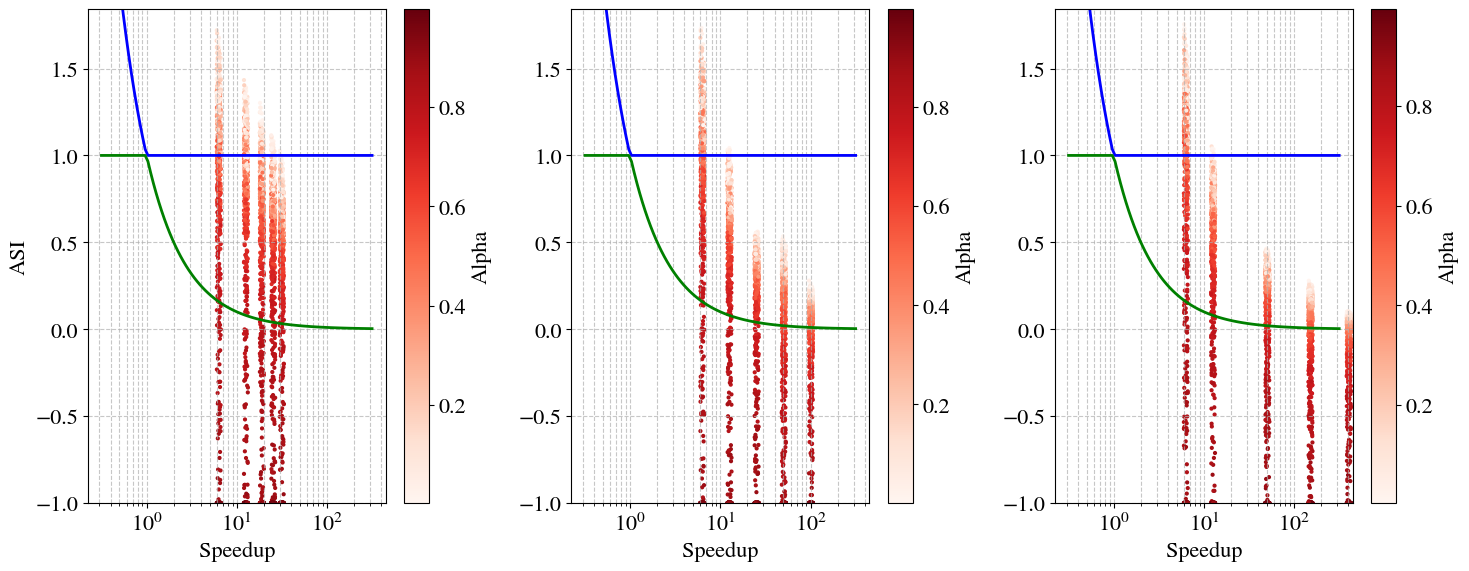

In [105]:
# ASI Framework separations
speedup_space = np.logspace(-0.5, 2.5, 100)

sep_strongly_sustainable = 1/speedup_space
sep_weakly_sustainable   = 1/speedup_space

sep_strongly_sustainable[np.where(sep_strongly_sustainable<1)] =1
sep_weakly_sustainable  [np.where(sep_weakly_sustainable>1)]   =1

# Plot the operation footprint vs FFT throughput
fig, ax = plt.subplots(1,3,figsize=(15, 6))
ax[0].set_ylabel('ASI')

for this_ax in ax:
    this_ax.plot(speedup_space, sep_strongly_sustainable, 'b', linewidth=2, label='Strongly Sustainable')
    this_ax.plot(speedup_space, sep_weakly_sustainable,   'g', linewidth=2, label='Weakly Sustainable')

    this_ax.set_xscale('log')
    this_ax.set_xlabel('Speedup')
    this_ax.set_ylim([-1,1.05*np.max(mc_asi_res)])
    this_ax.set_xlim([0,1.05*np.max(mc_speedup_ratio)])
    this_ax.grid(True, which='both', linestyle='--', alpha=0.7)
    #this_ax.set_xlim(10, 1e7)


for i in range(3):
    for j in range(0,arch_Dim):
        idx = np.where((mc_strat==i) & (mc_arch==j)) 
        distr = mc_asi_res[idx]
        speedu_distr = mc_speedup_ratio[idx]
        aplha_dist = mc_alpha[idx]
        p = ax[i].scatter(speedu_distr,   np.maximum(distr,-1),   c=aplha_dist,cmap="Reds",  s=4, label='Our Accelerator')
    fig.colorbar(p,ax=ax[i],orientation='vertical',label='Alpha')

# Add legend
fig.tight_layout()
plt.show()


C:\Users\Pol Maistriaux\AppData\Local\Temp\ipykernel_32052\682479300.py:19: UserWarning:

Attempt to set non-positive xlim on a log-scaled axis will be ignored.



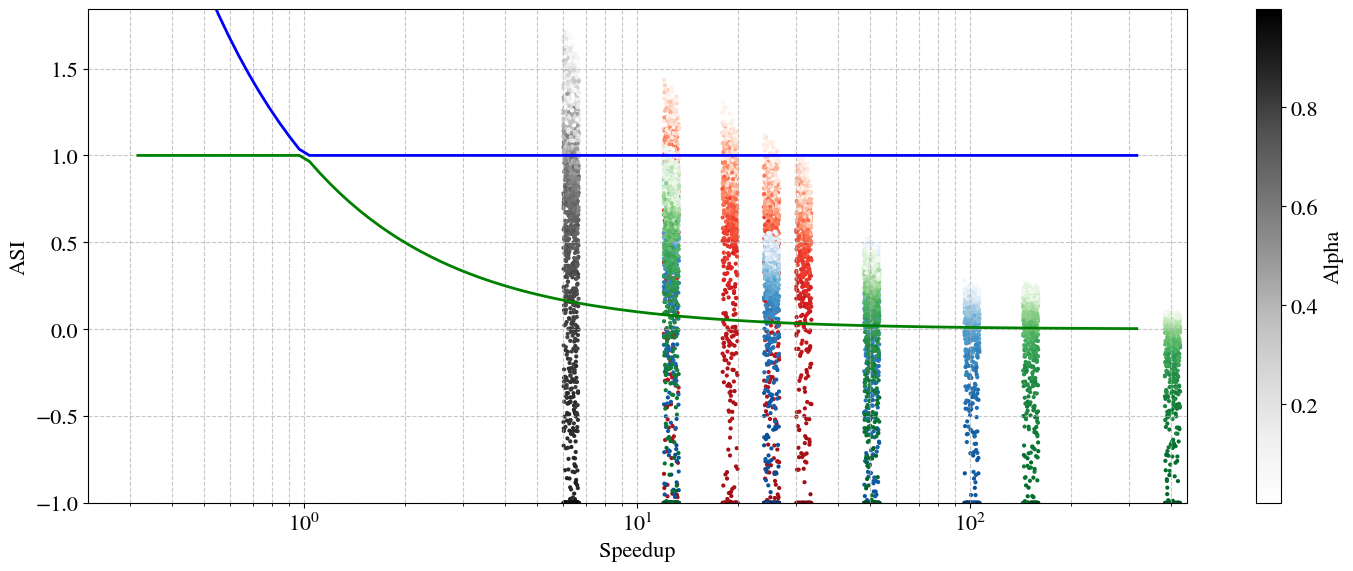

In [106]:
# ASI Framework separations
speedup_space = np.logspace(-0.5, 2.5, 100)

sep_strongly_sustainable = 1/speedup_space
sep_weakly_sustainable   = 1/speedup_space

sep_strongly_sustainable[np.where(sep_strongly_sustainable<1)] =1
sep_weakly_sustainable  [np.where(sep_weakly_sustainable>1)]   =1

# Plot the operation footprint vs FFT throughput
fig, ax = plt.subplots(1,1,figsize=(15, 6))
ax.set_ylabel('ASI')

ax.plot(speedup_space, sep_strongly_sustainable, 'b', linewidth=2, label='Strongly Sustainable')
ax.plot(speedup_space, sep_weakly_sustainable,   'g', linewidth=2, label='Weakly Sustainable')
ax.set_xscale('log')
ax.set_xlabel('Speedup')
ax.set_ylim([-1,1.05*np.max(mc_asi_res)])
ax.set_xlim([0,1.05*np.max(mc_speedup_ratio)])
ax.grid(True, which='both', linestyle='--', alpha=0.7)
#this_ax.set_xlim(10, 1e7)


arch_color_map = ['Reds', 'Blues', 'Greens']
for i in range(3):
    for j in range(1,arch_Dim):
        idx = np.where((mc_strat==i) & (mc_arch==j)) 
        distr = mc_asi_res[idx]
        speedu_distr = mc_speedup_ratio[idx]
        aplha_dist = mc_alpha[idx]
        p = ax.scatter(speedu_distr,   np.maximum(distr,-1),   c=aplha_dist,cmap=arch_color_map[i],  s=4)

idx = np.where(mc_arch==0) 
distr = mc_asi_res[idx]
speedu_distr = mc_speedup_ratio[idx]
aplha_dist = mc_alpha[idx]
p = ax.scatter(speedu_distr,   np.maximum(distr,-1),   c=aplha_dist,cmap="Greys",  s=4)

fig.colorbar(p,ax=ax,orientation='vertical',label='Alpha')

# Add legend
fig.tight_layout()
plt.show()


C:\Users\Pol Maistriaux\AppData\Local\Temp\ipykernel_32052\136105890.py:34: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

C:\Users\Pol Maistriaux\AppData\Local\Temp\ipykernel_32052\136105890.py:38: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



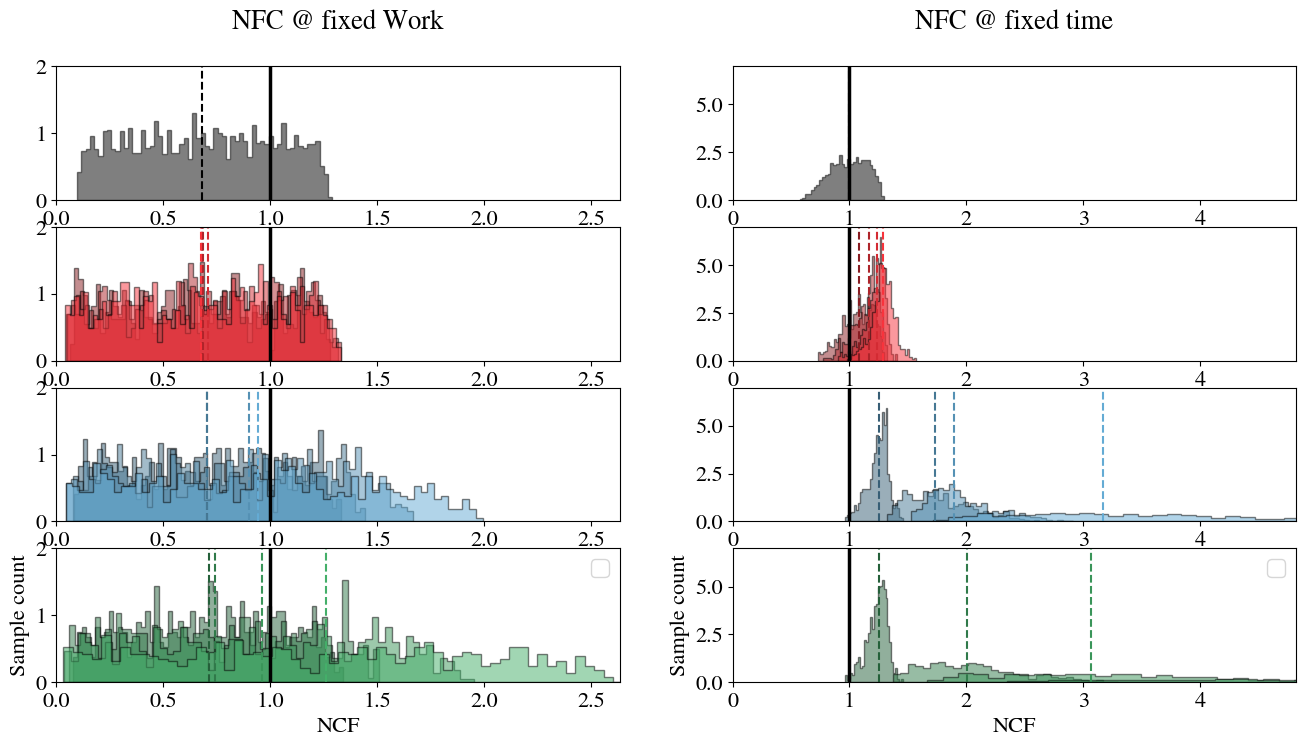

In [117]:
fig, axes = plt.subplots(4, 2, figsize=(16, 8),  sharey='col')

nbins_fw = 60
nbins_ft = 30
# (a) NCF ratio distribution
ax = axes
distr = mc_ncf_fw_res[np.where((mc_arch==0)) ]
ax[0,0].hist(distr, bins=nbins_fw,color = "black", edgecolor="black" , alpha=0.5,histtype='stepfilled',  fill=True,linewidth = 1,density=True) # ec='black',
ax[0,0].axvline(np.median(distr), color='black', linestyle='--', linewidth=1.5)


distr = mc_ncf_ft_res[np.where((mc_arch==0)) ]
ax[0,1].hist(mc_ncf_ft_res[np.where((mc_arch==0)) ], bins=nbins_ft,color = "black", edgecolor="black" , alpha=0.5,histtype='stepfilled',  fill=True,linewidth = 1,density=True) # ec='black',
ax[0,1].axvline(np.median(distr), color='black', linestyle='--', linewidth=1.5)

for i in range(3):
    #for j in [1, arch_Dim-1]:
    for j in range(1,arch_Dim):
        idx = np.where((mc_strat==i) & (mc_arch==j)) 

        distr = mc_ncf_fw_res[idx]
        ax[i+1,0].hist(distr, bins=nbins_fw,color = color_array[i,j], edgecolor="black" , alpha=0.5,histtype='stepfilled',  fill=True, density=True) 
        ax[i+1,0].axvline(np.median(distr), color = color_array[i,j], linestyle='--', linewidth=1.5)

        distr = mc_ncf_ft_res[idx]
        ax[i+1,1].hist(distr, bins=nbins_ft,color = color_array[i,j], edgecolor="black" , alpha=0.5,histtype='stepfilled',  fill=True, density=True) 
        ax[i+1,1].axvline(np.median(distr), color = color_array[i,j], linestyle='--', linewidth=1.5)

ax[0,0].set_title(f'NFC @ fixed Work\n')
ax[0,1].set_title(f'NFC @ fixed time\n')

ax[3,0].set_xlabel('NCF')
ax[3,0].set_ylabel('Sample count')
ax[3,0].legend()

ax[3,1].set_xlabel('NCF')
ax[3,1].set_ylabel('Sample count')
ax[3,1].legend()

ax[0,0].set_xlim(0, 1.05*np.percentile(mc_ncf_fw_res, 99.9))
ax[1,0].set_xlim(0, 1.05*np.percentile(mc_ncf_fw_res, 99.9))
ax[2,0].set_xlim(0, 1.05*np.percentile(mc_ncf_fw_res, 99.9))
ax[3,0].set_xlim(0, 1.05*np.percentile(mc_ncf_fw_res, 99.9))
ax[0,1].set_xlim(0, np.percentile(mc_ncf_ft_res, 95))
ax[1,1].set_xlim(0, np.percentile(mc_ncf_ft_res, 95))
ax[2,1].set_xlim(0, np.percentile(mc_ncf_ft_res, 95))
ax[3,1].set_xlim(0, np.percentile(mc_ncf_ft_res, 95))


ax[2,0].set_ylim(0, 2)
ax[3,1].set_ylim(0, 7)


ax[0,0].axvline(1, color='black', linestyle='-', linewidth=2.5)
ax[1,0].axvline(1, color='black', linestyle='-', linewidth=2.5)
ax[2,0].axvline(1, color='black', linestyle='-', linewidth=2.5)
ax[3,0].axvline(1, color='black', linestyle='-', linewidth=2.5)
ax[0,1].axvline(1, color='black', linestyle='-', linewidth=2.5)
ax[1,1].axvline(1, color='black', linestyle='-', linewidth=2.5)
ax[2,1].axvline(1, color='black', linestyle='-', linewidth=2.5)
ax[3,1].axvline(1, color='black', linestyle='-', linewidth=2.5)